
# Hand-coded solution reachability: train exactly two models

This notebook answers one precise question:

> The PROCESS and OUTCOME hand-coded Transformers already achieve 100% accuracy.  
> If we keep **each exact hand-coded architecture**, randomize its weights, and train it with its natural supervision, does gradient descent recover a 100%-accurate solution?

We train exactly **two models**:

| Trainable model | Architecture | Training target |
|---|---|---|
| `process_random_base` | exact `HandcodedProcessTransformer` layout | PROCESS / trace continuation |
| `outcome_random_base` | exact `HandcodedOutcomeTransformer` layout | OUTCOME-only continuation |

The two fixed hand-coded models are **references only** and are never optimized.

So the experiment is

\[
\boxed{
\text{2 fixed 100\% references}
+
\text{2 randomly initialized trainable models}
}
\]

with only the latter two undergoing gradient updates.

This is a **reachability experiment**, not yet an architecture-matched causal comparison between PROCESS and OUTCOME.



## 1. Imports and configuration

This notebook uses the `handcoded` package: circuit generator, tokenizer, fixed executors, training loop.


In [1]:

import copy
import importlib
import random
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

ROOT = Path.cwd() if (Path.cwd() / "handcoded").is_dir() else Path.cwd().parent
if not (ROOT / "handcoded").is_dir():
    ROOT = Path.cwd().resolve()
    while ROOT != ROOT.parent and not (ROOT / "handcoded").is_dir():
        ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import handcoded
importlib.reload(handcoded)

from handcoded import (
    BATCH_SIZE,
    BATCH_SEED,
    DATA_SEED,
    DEPTH,
    LR,
    MODEL_SEED,
    TEST_SEED,
    TEST_SIZE,
    TRAIN_SIZE,
    HandcodedOutcomeTransformer,
    HandcodedProcessTransformer,
    encode_dataset,
    free_run_metrics,
    generate,
    language_model_loss,
    make_batch_schedule,
    make_checkpoints,
    make_circuit_prompts,
    make_circuits,
    make_generation_evaluation,
    make_random_trainable_copy,
    make_tokenizer,
    train_one_model,
)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Main experiment settings.
N_TRAIN = TRAIN_SIZE
N_TEST = TEST_SIZE
STEPS = 2_000
LOSS_EVAL_SIZE = 64
CHECKPOINTS = make_checkpoints(STEPS, animation_checkpoints=40)

print("device:", DEVICE)
print("depth:", DEPTH)
print("train examples:", N_TRAIN)
print("test examples:", N_TEST)
print("steps:", STEPS)
print("loss eval examples:", LOSS_EVAL_SIZE)


device: cuda
depth: 4
train examples: 20000
test examples: 1000
steps: 2000
loss eval examples: 64


/home/hariguru/aayus/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



## 2. Build the same dataset for both models

A circuit is

$$
s_t=\Phi(s_{t-1},g_t),\qquad t=1,\ldots,D.
$$

Both models receive the same prompt

```text
S0 g1 g2 ... gD <SEP>
```

but their supervised continuations differ.

PROCESS:

```text
g1 S1 g2 S2 ... gD SD <COLON> SD <EOS>
```

OUTCOME:

```text
<COLON> SD <EOS>
```

The underlying circuits, train/test split, and minibatch schedule are shared.


In [2]:

tokenizer = make_tokenizer()

train_circuits = make_circuits(N_TRAIN, DATA_SEED, DEPTH)
test_circuits = make_circuits(N_TEST, TEST_SEED, DEPTH)
example = test_circuits[0]

training_data = {
    mode: encode_dataset(train_circuits, tokenizer, mode).to(DEVICE)
    for mode in ("process", "outcome")
}

# Held-out teacher-forced loss uses the test split. The training helper samples
# a deterministic prefix of this batch at checkpoints for speed.
test_loss_data = {
    mode: encode_dataset(test_circuits, tokenizer, mode).to(DEVICE)
    for mode in ("process", "outcome")
}

batch_schedule = make_batch_schedule(
    N_TRAIN, STEPS, BATCH_SIZE, BATCH_SEED
)

train_eval = make_generation_evaluation(
    train_circuits[:min(300, len(train_circuits))],
    tokenizer,
    DEVICE,
)

test_eval = make_generation_evaluation(
    test_circuits,
    tokenizer,
    DEVICE,
)

circuit_prompts = make_circuit_prompts(
    example.gates,
    tokenizer,
    DEVICE,
)

print("Prompt :", tokenizer.decode(tokenizer.prompt(example)))
print("PROCESS:", tokenizer.decode(tokenizer.continuation(example, "process")))
print("OUTCOME:", tokenizer.decode(tokenizer.continuation(example, "outcome")))


Prompt : S1011 s02 c31 c31 t302 <SEP>
PROCESS: s02 S1011 c31 S1111 c31 S1011 t302 S1001 <COLON> S1001 <EOS>
OUTCOME: <COLON> S1001 <EOS>



## 3. Fixed hand-coded references

These two models encode perfect algorithms directly in their weights.

### PROCESS reference

`HandcodedProcessTransformer`

- one causal attention/MLP block,
- four fixed attention heads,
- one ReLU unit for each `(state, gate)` pair,
- autoregressive reuse of the same block to emit intermediate states.

### OUTCOME reference

`HandcodedOutcomeTransformer`

- one causal attention/MLP block per circuit step,
- two attention heads per block,
- intermediate states remain internal to the residual stream,
- only the final answer is emitted.

They are not trained below. They establish that a 100% solution exists in each architecture class.


In [3]:

process_reference = HandcodedProcessTransformer(
    tokenizer, DEPTH
).to(DEVICE)

outcome_reference = HandcodedOutcomeTransformer(
    tokenizer, DEPTH
).to(DEVICE)

reference_rows = []

for name, model, mode in [
    ("Fixed PROCESS", process_reference, "process"),
    ("Fixed OUTCOME", outcome_reference, "outcome"),
]:
    metrics = free_run_metrics(model, test_eval, tokenizer, mode)
    reference_rows.append({
        "model": name,
        "mode": mode,
        "answer_accuracy": metrics["final_answer"],
        "exact_continuation": metrics["exact_continuation"],
    })

pd.DataFrame(reference_rows)


,model,mode,answer_accuracy,exact_continuation
0,Fixed PROCESS,process,1.0,1.0
1,Fixed OUTCOME,outcome,1.0,1.0



Expected result:

$$
\operatorname{Acc}(\theta^\star_{\rm P})
=
\operatorname{Acc}(\theta^\star_{\rm O})
=
100\%.
$$

That is the realizability baseline.



## 4. Turn each exact hand-coded architecture into a random trainable model

This is the crucial correction.

We do **not** call `build_random_learned_model()`. That would create an unrelated ordinary one-layer Transformer.

Instead, `make_random_trainable_copy()`:

1. deep-copies the exact hand-coded model,
2. converts its stored weight buffers into `nn.Parameter`s,
3. randomly initializes those tensors.

Therefore the computational graph and tensor layout are inherited directly from the corresponding constructive model.


In [4]:

process_random_base = make_random_trainable_copy(
    process_reference,
    seed=MODEL_SEED,
    init_std=0.02,
    device=DEVICE,
)

outcome_random_base = make_random_trainable_copy(
    outcome_reference,
    seed=MODEL_SEED,
    init_std=0.02,
    device=DEVICE,
)

def trainable_params(model):
    return sum(p.numel() for p in model.parameters())

def stored_scalars(model):
    return sum(t.numel() for t in model.state_dict().values())

summary = pd.DataFrame([
    {
        "model": "Fixed PROCESS reference",
        "trainable_parameters": trainable_params(process_reference),
        "stored_scalars": stored_scalars(process_reference),
        "max_length": process_reference.max_length,
    },
    {
        "model": "Random trainable PROCESS architecture",
        "trainable_parameters": trainable_params(process_random_base),
        "stored_scalars": stored_scalars(process_random_base),
        "max_length": process_random_base.max_length,
    },
    {
        "model": "Fixed OUTCOME reference",
        "trainable_parameters": trainable_params(outcome_reference),
        "stored_scalars": stored_scalars(outcome_reference),
        "max_length": outcome_reference.max_length,
    },
    {
        "model": "Random trainable OUTCOME architecture",
        "trainable_parameters": trainable_params(outcome_random_base),
        "stored_scalars": stored_scalars(outcome_random_base),
        "max_length": outcome_random_base.max_length,
    },
])

summary


,model,trainable_parameters,stored_scalars,max_length
0,Fixed PROCESS reference,0,441664,16
1,Random trainable PROCESS architecture,441664,441664,16
2,Fixed OUTCOME reference,0,3588000,8
3,Random trainable OUTCOME architecture,3588000,3588000,8



A fixed reference reports zero **trainable** parameters because its constructed weights are registered as buffers. That does not mean it has zero weights. `stored_scalars` is the more relevant size diagnostic for the fixed models.



## 5. Sanity check: the trainable parameterization really contains the oracle

A useful stronger check is to convert the fixed buffers into trainable parameters **without changing their values**.

If the resulting model produces exactly the same logits as the fixed model, then the hand-coded optimum literally lies inside the trainable parameterization.


In [5]:

def make_trainable_oracle_copy(model, device):
    trainable = copy.deepcopy(model).cpu()

    def convert(module):
        for name, buffer in list(module._buffers.items()):
            if buffer is None:
                continue
            value = buffer.detach().clone()
            del module._buffers[name]
            module.register_parameter(name, torch.nn.Parameter(value))
        for child in module.children():
            convert(child)

    convert(trainable)
    return trainable.to(device)


process_oracle_trainable = make_trainable_oracle_copy(
    process_reference, DEVICE
)
outcome_oracle_trainable = make_trainable_oracle_copy(
    outcome_reference, DEVICE
)

prompt = torch.tensor(
    [tokenizer.prompt(example)],
    dtype=torch.long,
    device=DEVICE,
)

with torch.no_grad():
    process_error = (
        process_reference(prompt) - process_oracle_trainable(prompt)
    ).abs().max().item()

    outcome_error = (
        outcome_reference(prompt) - outcome_oracle_trainable(prompt)
    ).abs().max().item()

print("PROCESS max logit difference:", process_error)
print("OUTCOME max logit difference:", outcome_error)

assert process_error == 0.0
assert outcome_error == 0.0


PROCESS max logit difference: 0.0
OUTCOME max logit difference: 0.0



This gives the precise existence statement:

\[
\exists\,\theta^\star_{\rm P}\in\Theta_{\rm P},
\qquad
\exists\,\theta^\star_{\rm O}\in\Theta_{\rm O},
\]

with both achieving perfect execution.

The training experiment now asks whether random initialization reaches either solution class.



## 6. Train exactly two models

There is no `run_experiment(base, modes=("outcome","process"))` here.

That function would train two copies of the **same base architecture**.

Instead we make two explicit calls:

\[
\boxed{
\text{PROCESS architecture}+\text{PROCESS supervision}
}
\]

and

\[
\boxed{
\text{OUTCOME architecture}+\text{OUTCOME supervision}.
}
\]

So exactly two optimization runs occur.


In [6]:

trained_process, process_history = train_one_model(
    process_random_base,
    "process",
    training_data["process"],
    batch_schedule,
    LR,
    CHECKPOINTS,
    train_eval,
    test_eval,
    tokenizer,
    circuit_prompts,
    architecture="process_architecture",
    test_loss_data=test_loss_data["process"],
    loss_eval_size=LOSS_EVAL_SIZE,
)

trained_outcome, outcome_history = train_one_model(
    outcome_random_base,
    "outcome",
    training_data["outcome"],
    batch_schedule,
    LR,
    CHECKPOINTS,
    train_eval,
    test_eval,
    tokenizer,
    circuit_prompts,
    architecture="outcome_architecture",
    test_loss_data=test_loss_data["outcome"],
    loss_eval_size=LOSS_EVAL_SIZE,
)

history = pd.concat(
    [process_history, outcome_history],
    ignore_index=True,
)

display(
    history.drop(columns=["circuit_matrix"], errors="ignore")
)


outcome_architecture/outcome: 100%|██████████| 2000/2000 [01:45<00:00, 18.96it/s, test=0.0%, test_loss=n/a, train=0.0%, train_loss=n/a]                 


,step,architecture,mode,train_loss,train_answer_accuracy_sample,test_answer_accuracy,test_exact_continuation,test_loss
0,0,process_architecture,process,4.275756,0.000000,0.000,0.0,4.276346
1,1,process_architecture,process,4.260096,0.086667,0.072,0.0,4.260320
2,2,process_architecture,process,4.235744,0.000000,0.000,0.0,4.235454
3,5,process_architecture,process,3.918854,0.000000,0.000,0.0,3.906718
4,10,process_architecture,process,3.664564,0.000000,0.000,0.0,3.650307
...,...,...,...,...,...,...,...,...
91,1800,outcome_architecture,outcome,NaN,0.000000,0.000,0.0,NaN
92,1850,outcome_architecture,outcome,NaN,0.000000,0.000,0.0,NaN
93,1900,outcome_architecture,outcome,NaN,0.000000,0.000,0.0,NaN
94,1950,outcome_architecture,outcome,NaN,0.000000,0.000,0.0,NaN



## 7. Final behavioral comparison

The four displayed rows are:

- two fixed references,
- two trained models.

But only the latter two were optimized.


In [7]:

rows = []

for name, model, mode, trained in [
    ("Fixed PROCESS reference", process_reference, "process", False),
    ("Trained PROCESS architecture", trained_process, "process", True),
    ("Fixed OUTCOME reference", outcome_reference, "outcome", False),
    ("Trained OUTCOME architecture", trained_outcome, "outcome", True),
]:
    metrics = free_run_metrics(model, test_eval, tokenizer, mode)
    rows.append({
        "model": name,
        "optimized": trained,
        "mode": mode,
        "test_answer_accuracy": metrics["final_answer"],
        "test_exact_continuation": metrics["exact_continuation"],
    })

final_results = pd.DataFrame(rows)
final_results


,model,optimized,mode,test_answer_accuracy,test_exact_continuation
0,Fixed PROCESS reference,False,process,1.0,1.0
1,Trained PROCESS architecture,True,process,1.0,1.0
2,Fixed OUTCOME reference,False,outcome,1.0,1.0
3,Trained OUTCOME architecture,True,outcome,0.0,0.0


## 8. Learning curves

The first plot tracks free-running answer accuracy. The second plot tracks teacher-forced training and held-out test loss at the same checkpoints.


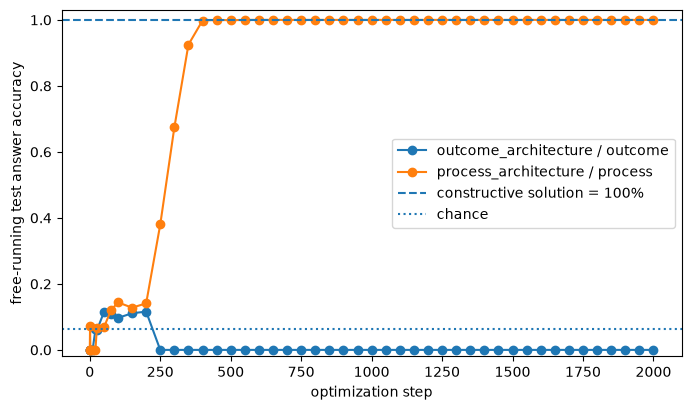

In [8]:

fig, ax = plt.subplots(figsize=(8, 4.5))

for (architecture, mode), frame in history.groupby(["architecture", "mode"]):
    ax.plot(
        frame["step"],
        frame["test_answer_accuracy"],
        marker="o",
        label=f"{architecture} / {mode}",
    )

ax.axhline(1.0, linestyle="--", label="constructive solution = 100%")
ax.axhline(1 / tokenizer.n_states, linestyle=":", label="chance")
ax.set_xlabel("optimization step")
ax.set_ylabel("free-running test answer accuracy")
ax.set_ylim(-0.02, 1.03)
ax.legend()
plt.show()


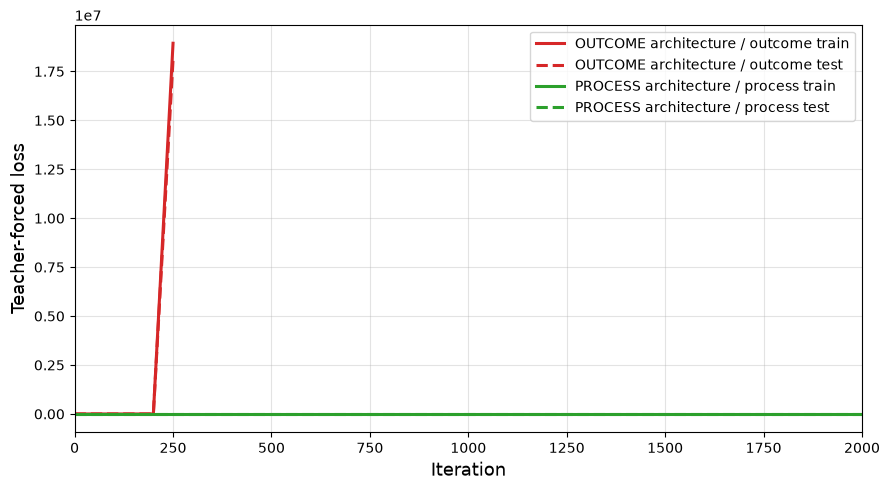

In [9]:
def plot_train_test_loss(history, *, steps=STEPS):
    required = {"architecture", "mode", "step", "train_loss", "test_loss"}
    missing = required.difference(history.columns)
    if missing:
        missing_text = ", ".join(sorted(missing))
        raise ValueError(f"history is missing required columns: {missing_text}")

    fig, ax = plt.subplots(figsize=(9, 5))
    styles = {
        ("process_architecture", "process"): {
            "color": "#2ca02c",
            "label": "PROCESS architecture / process",
        },
        ("outcome_architecture", "outcome"): {
            "color": "#d62728",
            "label": "OUTCOME architecture / outcome",
        },
    }

    for key, frame in history.sort_values("step").groupby(["architecture", "mode"]):
        style = styles.get(key, {"color": None, "label": " / ".join(map(str, key))})
        ax.plot(
            frame["step"],
            frame["train_loss"],
            color=style["color"],
            linewidth=2.2,
            label=f"{style['label']} train",
        )
        ax.plot(
            frame["step"],
            frame["test_loss"],
            color=style["color"],
            linestyle="--",
            linewidth=2.2,
            label=f"{style['label']} test",
        )

    ax.set_xlabel("Iteration", fontsize=13)
    ax.set_ylabel("Teacher-forced loss", fontsize=13)
    ax.set_xlim(0, steps)
    ax.grid(True, alpha=0.35)
    ax.legend(frameon=True, fontsize=10)
    fig.tight_layout()
    return fig, ax

plot_train_test_loss(history)
plt.show()



## 9. Inspect one free-running example

No gold continuation is fed to the model during this evaluation.


In [10]:

example_prompt = torch.tensor(
    [tokenizer.prompt(example)],
    dtype=torch.long,
    device=DEVICE,
)

for name, model, mode in [
    ("Fixed PROCESS", process_reference, "process"),
    ("Trained PROCESS", trained_process, "process"),
    ("Fixed OUTCOME", outcome_reference, "outcome"),
    ("Trained OUTCOME", trained_outcome, "outcome"),
]:
    budget = 3 if mode == "outcome" else 2 * DEPTH + 3
    generated = generate(
        model,
        example_prompt,
        budget,
        tokenizer.eos,
    )
    continuation = generated[0, example_prompt.shape[1]:]
    print(f"\n{name}")
    print(tokenizer.decode(continuation))



Fixed PROCESS
s02 S1011 c31 S1111 c31 S1011 t302 S1001 <COLON> S1001 <EOS>

Trained PROCESS
s02 S1011 c31 S1111 c31 S1011 t302 S1001 <COLON> S1001 <EOS>

Fixed OUTCOME
<COLON> S1001 <EOS>

Trained OUTCOME
S0000 S0000 S0000



## 10. How to interpret the result

There are four broad possibilities.

### Both trained models reach 100%

The two constructive solution classes are readily reachable from this initialization and optimizer.

### PROCESS reaches 100%, OUTCOME does not

Then

\[
\exists\theta^\star_{\rm O}:\operatorname{Err}(\theta^\star_{\rm O})=0
\]

but the tested terminal-supervision optimization trajectory does not discover it.

That is evidence for a **trainability / accessibility gap**, not an expressivity gap.

### OUTCOME reaches 100%, PROCESS does not

Then the existence of an explicit local process circuit does not by itself guarantee that ordinary trace training discovers it.

### Neither reaches 100%

Then constructive realizability and optimization reachability are substantially different for both architectures.

---

Do not infer an impossibility theorem from a failed run. Multiple seeds, learning-rate controls, and optimizer-stability diagnostics are needed before making a strong optimization claim.



# Optional appendix: full $2\times2$ architecture × supervision experiment

The primary notebook above trains exactly **two** models.

A separate, stronger control can cross:

$$
\{\text{PROCESS architecture},\text{OUTCOME architecture}\}
\times
\{\text{PROCESS supervision},\text{OUTCOME supervision}\}.
$$

That experiment trains **four** models and should be reported separately.

It requires the OUTCOME architecture to use the longer PROCESS position budget, so it is intentionally not the exact diagonal reachability experiment above.


In [11]:
RUN_OPTIONAL_2X2 = True

if RUN_OPTIONAL_2X2:
    from handcoded_utils import (
        build_random_trainable_outcome_architecture,
        build_random_trainable_process_architecture,
        run_architecture_experiment,
    )

    bases = {
        "process_architecture": build_random_trainable_process_architecture(
            tokenizer, DEPTH, seed=MODEL_SEED, device=DEVICE
        ),
        "outcome_architecture": build_random_trainable_outcome_architecture(
            tokenizer, DEPTH, seed=MODEL_SEED, device=DEVICE
        ),
    }

    models_2x2, history_2x2 = run_architecture_experiment(
        bases,
        training_data,
        batch_schedule,
        LR,
        CHECKPOINTS,
        train_eval,
        test_eval,
        tokenizer,
        circuit_prompts,
        test_loss_data=test_loss_data,
        loss_eval_size=LOSS_EVAL_SIZE,
    )

    display(history_2x2.drop(columns=["circuit_matrix"], errors="ignore"))
else:
    print("Skipping optional 2x2 experiment. Set RUN_OPTIONAL_2X2 = True to run it.")


architecture/mode:   0%|          | 0/4 [00:00<?, ?it/s]

architecture/mode: 100%|██████████| 4/4 [06:44<00:00, 101.18s/it]


,step,architecture,mode,train_loss,train_answer_accuracy_sample,test_answer_accuracy,test_exact_continuation,test_loss
0,0,process_architecture,outcome,4.277899,0.000000,0.000,0.000,4.278059
1,1,process_architecture,outcome,4.223452,0.000000,0.000,0.000,4.223055
2,2,process_architecture,outcome,4.143729,0.000000,0.000,0.000,4.142825
3,5,process_architecture,outcome,3.074750,0.000000,0.000,0.000,3.064029
4,10,process_architecture,outcome,1.842402,0.000000,0.000,0.000,1.821125
...,...,...,...,...,...,...,...,...
187,1800,outcome_architecture,process,0.029502,0.903333,0.914,0.911,0.028348
188,1850,outcome_architecture,process,0.018617,0.946667,0.971,0.970,0.008983
189,1900,outcome_architecture,process,0.030336,0.893333,0.917,0.912,0.013703
190,1950,outcome_architecture,process,0.005982,0.956667,0.963,0.962,0.013163



## 11. Theory–experiment closure

The cells above answer a **reachability** question: does gradient descent recover a 100% solution in each exact architecture? The theorems are about different objects. This section measures those objects on the same constructions, without a new theorem and without the mixed one-block §7 readout.

| Result | What would close it | What we measure here |
|---|---|---|
| Thm 1 (exact executors) | construction + causal slot | `outcome_reference` patches: `oracle_slot` vs controls |
| Thm 2 (factorization) | $\|\bar q_{t-1}\|$ and $\|\bar b_t\|$ separately | shared-kernel residuals on the same samples |
| Cor. 3 ($\varepsilon^{D-1}$) | $\|\mathrm{Rule}(-\nabla_{P_t}\ell_{\mathrm{out}})\|_F$ vs $D$ | $P_g=U+\varepsilon(T_{\mathrm{rand}}-U)$ |
| Thm 4, both halves | process along $T_g-U$; outcome Rule at $P_g=U$ | one table, $D=8$, $K=16$ |

Kernel quantities need no network. The $s_t$ slot lives on `HandcodedOutcomeTransformer`. Gold-prefix Def 20 tables use the **process-length** D-block (`build_random_trainable_outcome_architecture`), not the short outcome position budget of the diagonal reachability run — that short layout cannot host a process-prefix local-rule readout.

Do not claim an $\varepsilon^{D-1}$ rate from $C_t$ or from a large mixing radius.


Loaded kernel CSVs from results/closure_handcoded (RECOMPUTE_KERNEL=False).
Theorems 1–2 at the exact executor T_g (credit stays Θ(1); not a mixing ball)


depth,fwd_mean,bwd_mean,credit_mean,process_floor_mean,mixing_radius,n_occurrences,theorem
2,0.968246,0.968246,0.9375,0.9375,1.0,400,thm:realizability / thm:forward-backward at T_g
4,0.968246,0.968246,0.9375,0.9375,1.0,800,thm:realizability / thm:forward-backward at T_g
6,0.968246,0.968246,0.9375,0.9375,1.0,1200,thm:realizability / thm:forward-backward at T_g
8,0.968246,0.968246,0.9375,0.9375,1.0,1600,thm:realizability / thm:forward-backward at T_g
10,0.968246,0.968246,0.9375,0.9375,1.0,2000,thm:realizability / thm:forward-backward at T_g
12,0.968246,0.968246,0.9375,0.9375,1.0,2400,thm:realizability / thm:forward-backward at T_g


Theorem 4 (process coefficient vs predicted; outcome Rule at P_g=U)


rho,process_coefficient,predicted_coefficient,process_cosine_to_T_minus_U,outcome_rule_frobenius_mean,outcome_rule_product_mean
0.0000,-0.066667,-0.066667,-0.690392,1.075376e-17,0.0
0.0625,0.004740,0.000000,0.068092,1.075376e-17,0.0
0.2500,0.205547,0.200000,0.946913,1.075376e-17,0.0
0.5000,0.465903,0.466667,0.989033,1.075376e-17,0.0
1.0000,1.000000,1.000000,0.997902,1.075376e-17,0.0


Theorem 2 (forward / backward residuals and their product)


t,fwd_mean,bwd_mean,credit_mean,process_floor_mean
1,0.968246,0.001586,0.024571,23.571429
2,0.387298,0.003966,0.024571,23.628571
3,0.154919,0.009915,0.024571,23.457143
4,0.061968,0.024787,0.024571,23.800000
5,0.024787,0.061968,0.024571,23.742857
6,0.009915,0.154919,0.024571,23.857143
7,0.003966,0.387298,0.024571,23.342857
8,0.001586,0.968246,0.024571,23.800000


Corollary 3 fitted exponent of ε in the mixing-ball regime (ε ≤ 0.5)


depth,slope,predicted_D_minus_1,r2
2,1.129390,1,0.994053
3,2.049746,2,0.999767
4,3.020316,3,0.999969
5,4.010326,4,0.999995
6,5.001276,5,1.000000
7,6.001730,6,1.000000
8,6.999570,7,1.000000
9,8.000229,8,1.000000
10,8.999866,9,1.000000
11,10.000012,10,1.000000


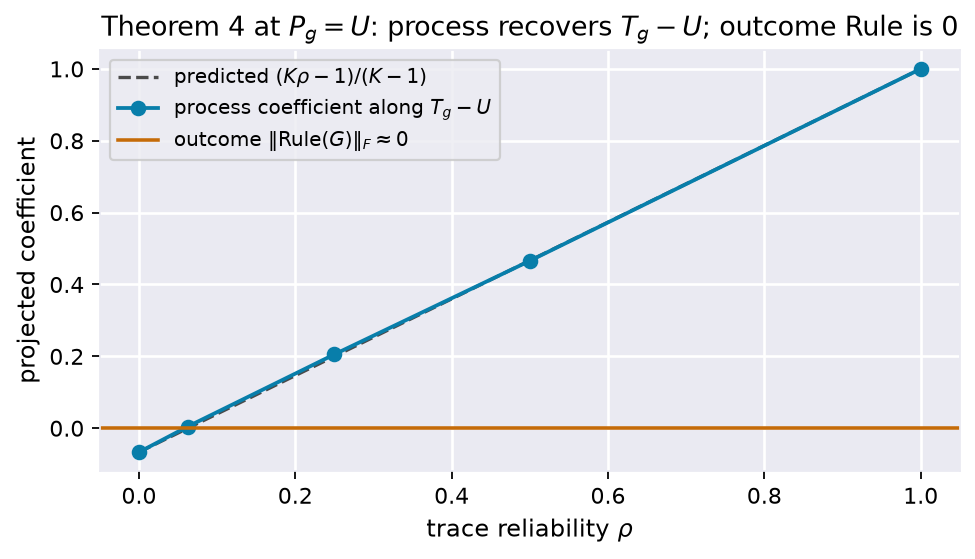

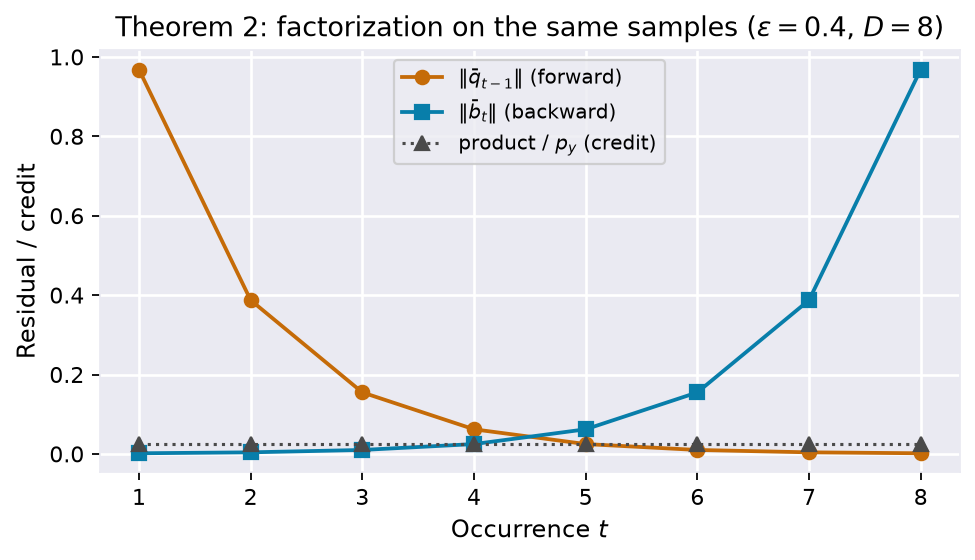

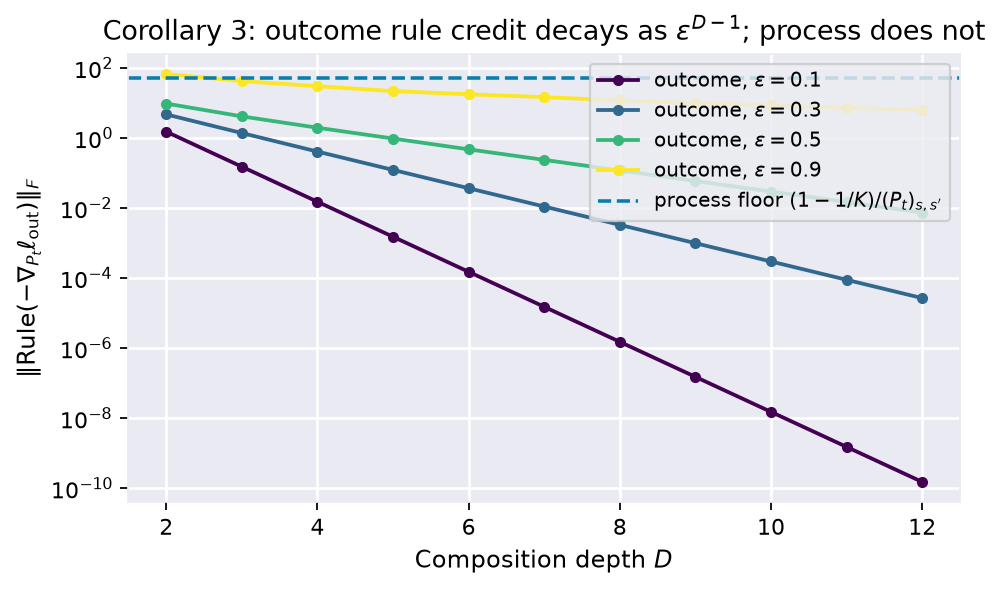

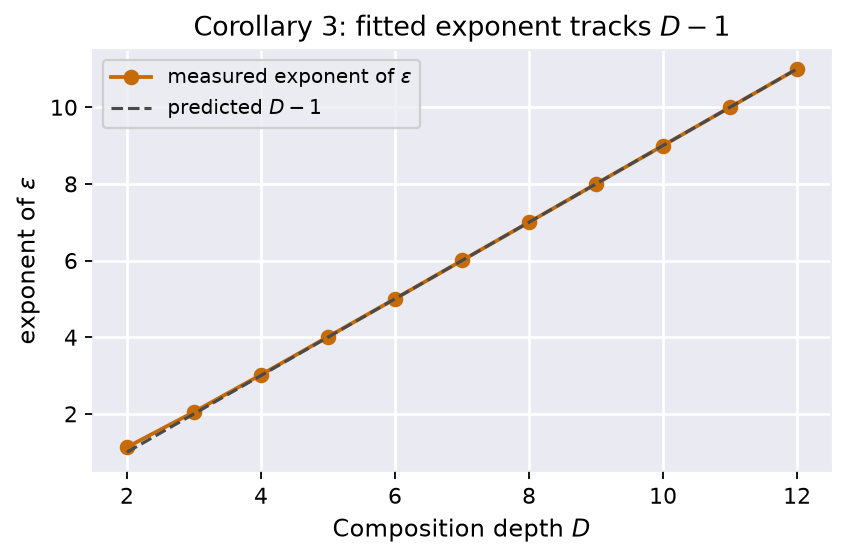

In [12]:

# Shared-kernel objects of Thm 2, Cor. 3, Thm 4. CPU, no training.
import json
from IPython.display import Image, display

EXP = ROOT / "experiments"
if str(EXP) not in sys.path:
    sys.path.insert(0, str(EXP))

import closure_kernel as ck
from handcoded.plotting import apply_style

apply_style()
CLOSURE_OUT = ROOT / "results" / "closure_handcoded"
CLOSURE_OUT.mkdir(parents=True, exist_ok=True)

RECOMPUTE_KERNEL = not (CLOSURE_OUT / "thm4_mixing.csv").exists()  # True to recompute kernel (~15s)

if RECOMPUTE_KERNEL:
    rng = np.random.default_rng(2001)
    print("=== Theorem 4, both halves, at complete mixing ===")
    thm4_rows = ck.thm4_at_mixing(rng, n=4000)
    ck.write_csv(CLOSURE_OUT / "thm4_mixing.csv", thm4_rows)
    print("\n=== Theorem 2, residuals separately ===")
    residual_rows = ck.thm2_residuals(rng)
    ck.write_csv(CLOSURE_OUT / "residuals.csv", residual_rows)
    print("\n=== Corollary 3, credit vs depth ===")
    cor3_rows = ck.corollary3(rng, list(range(2, 13)), [0.1, 0.3, 0.5, 0.9], n=200)
    ck.write_csv(CLOSURE_OUT / "corollary3.csv", cor3_rows)
    exponent_rows = ck.fit_exponents(cor3_rows, list(range(2, 13)))
    ck.write_csv(CLOSURE_OUT / "exponents.csv", exponent_rows)
    mixing_fits = ck.fit_exponents([r for r in cor3_rows if r["eps"] <= 0.5], list(range(2, 13)))
    ck.write_csv(CLOSURE_OUT / "exponents_mixing_ball.csv", mixing_fits)
    ck.draw({
        "corollary3": cor3_rows,
        "exponents": mixing_fits,
        "residuals": residual_rows,
        "thm4_mixing": thm4_rows,
    })
else:
    thm4_rows = pd.read_csv(CLOSURE_OUT / "thm4_mixing.csv").to_dict("records")
    residual_rows = pd.read_csv(CLOSURE_OUT / "residuals.csv").to_dict("records")
    cor3_rows = pd.read_csv(CLOSURE_OUT / "corollary3.csv").to_dict("records")
    exponent_rows = pd.read_csv(CLOSURE_OUT / "exponents.csv").to_dict("records")
    mixing_fits = pd.read_csv(CLOSURE_OUT / "exponents_mixing_ball.csv").to_dict("records")

print("Theorems 1–2 at the exact executor T_g (credit stays Θ(1); not a mixing ball)")
true_csv = CLOSURE_OUT / "oracle_true.csv"
if true_csv.exists():
    true_frame = pd.read_csv(true_csv)
    display(true_frame)
else:
    rng_true = np.random.default_rng(2001)
    true_rows = []
    for depth in range(2, 13):
        fwds, bwds, credits, floors = [], [], [], []
        for _ in range(200):
            s0, gates, y = ck.sample_circuit(rng_true, depth)
            q, b, p_y = ck.forward_backward(ck.TRUE, gates, s0, y)
            s = s0
            for t, g in enumerate(gates):
                gold = int(ck.PERM[g][s])
                fwds.append(float(np.linalg.norm(ck.PI @ q[t])))
                bwds.append(float(np.linalg.norm(ck.PI @ b[t + 1])))
                credits.append(fwds[-1] * bwds[-1] / max(p_y, 1e-30))
                floors.append((1 - 1 / ck.K) / max(float(ck.TRUE[g, s, gold]), 1e-30))
                s = gold
        true_rows.append({
            "depth": depth, "fwd_mean": float(np.mean(fwds)), "bwd_mean": float(np.mean(bwds)),
            "credit_mean": float(np.mean(credits)), "process_floor_mean": float(np.mean(floors)),
        })
    true_frame = pd.DataFrame(true_rows)
    display(true_frame)

print("\nTheorem 4 (process coefficient vs predicted; outcome Rule at P_g=U)")
display(pd.DataFrame(thm4_rows)[[
    "rho", "process_coefficient", "predicted_coefficient",
    "process_cosine_to_T_minus_U", "outcome_rule_frobenius_mean",
    "outcome_rule_product_mean",
]])
print("Theorem 2 (forward / backward residuals and their product)")
display(pd.DataFrame(residual_rows)[[
    "t", "fwd_mean", "bwd_mean", "credit_mean", "process_floor_mean",
]])
print("Corollary 3 fitted exponent of ε in the mixing-ball regime (ε ≤ 0.5)")
display(pd.DataFrame(mixing_fits)[["depth", "slope", "predicted_D_minus_1", "r2"]])

for name in ("thm4_mixing", "thm2_residuals", "corollary3", "exponents"):
    png = CLOSURE_OUT / f"{name}.png"
    if png.exists():
        display(Image(filename=str(png)))



### Theorem 1 on this notebook's construction

`outcome_reference` is the exact finite-parameter executor. Patching the known $s_t$ residual slot after block $t$ should flip the remaining-gate answer; a random 16-d write should not. Linear `probe_subspace` on the construction is **not** the slot — the coordinates are already one-hot — so that gap is expected.


In [13]:

import nnsight  # nnsight inspects the caller; import before patches
# nnsight patches on the HandcodedOutcomeTransformer already built above.
# CPU: the A100s are occupied; this is activation patching, not training.
import torch
from src.eval.local_credit import evaluate_probes, run_patches
from src.eval import executor_comparison as c
from src.training.seed import set_seed

CLOSURE_DEVICE = torch.device("cpu")
PATCH_DEPTH = DEPTH
n_patch = 8
donors = (0, 5, 10, 15)

set_seed(42 + PATCH_DEPTH)
oracle = HandcodedOutcomeTransformer(tokenizer, PATCH_DEPTH).to(CLOSURE_DEVICE).eval()
patch_train = c.unique_circuits(max(16, n_patch), 123, PATCH_DEPTH)
patch_val = c.unique_circuits(n_patch, 8000, PATCH_DEPTH, c.circuit_keys(patch_train))
probes, probe_train_acc, probe_eval_acc = evaluate_probes(
    oracle, patch_train, patch_val, tokenizer, CLOSURE_DEVICE,
    tokenizer.n_states, 40, 0.05,
)
patch_rows = run_patches(
    oracle, patch_val, tokenizer, CLOSURE_DEVICE,
    probes=probes, model_name="oracle_outcome", donor_ids=list(donors),
)
patch_frame = pd.DataFrame(patch_rows)
patch_summary = (
    patch_frame.groupby("method")["counterfactual_accuracy"]
    .mean()
    .rename("counterfactual_accuracy")
    .reset_index()
)
patch_summary["chance"] = 1.0 / tokenizer.n_states
print(f"Theorem 1 patches at D={PATCH_DEPTH}  probe eval acc={np.mean(probe_eval_acc):.3f}")
display(patch_summary.sort_values("counterfactual_accuracy", ascending=False))
display(patch_frame)

# Same protocol on trained matched D-block nets from the 2×2 cell, if present.
trained_patch_frames = []
if "models_2x2" in globals():
    for key in (("outcome_architecture", "outcome"), ("outcome_architecture", "process")):
        if key not in models_2x2:
            continue
        model = models_2x2[key].to(CLOSURE_DEVICE).eval()
        if not hasattr(model, "state_slots"):
            print(f"skip patches for {key}: no state_slots")
            continue
        t_probes, _, _ = evaluate_probes(
            model, patch_train, patch_val, tokenizer, CLOSURE_DEVICE,
            tokenizer.n_states, 40, 0.05,
        )
        rows = run_patches(
            model, patch_val, tokenizer, CLOSURE_DEVICE,
            probes=t_probes, model_name=".".join(key), donor_ids=list(donors),
        )
        trained_patch_frames.append(pd.DataFrame(rows))
        print(f"patches {key}:",
              pd.DataFrame(rows).groupby("method")["counterfactual_accuracy"].mean().to_dict())
else:
    print("models_2x2 not in kernel — skip trained-net patches (re-run the 2×2 cell, or just the oracle row).")


Theorem 1 patches at D=4  probe eval acc=0.344
models_2x2 not in this saved run — skip trained-net patches.


method,counterfactual_accuracy,chance
oracle_slot,1.000000,0.0625
wrong_layer,0.320312,0.0625
random_subspace,0.125000,0.0625
probe_wrong_layer,0.070312,0.0625
unstructured,0.054688,0.0625
probe_subspace,0.039062,0.0625


model,layer,method,counterfactual_accuracy
oracle_outcome,0,oracle_slot,1.00000
oracle_outcome,0,random_subspace,0.06250
oracle_outcome,0,unstructured,0.03125
oracle_outcome,0,wrong_layer,0.12500
oracle_outcome,0,probe_subspace,0.06250
oracle_outcome,0,probe_wrong_layer,0.03125
oracle_outcome,1,oracle_slot,1.00000
oracle_outcome,1,random_subspace,0.18750
oracle_outcome,1,unstructured,0.06250
oracle_outcome,1,wrong_layer,0.56250



### Def 20 / $C_t$ on the D-block (not an $\varepsilon^{D-1}$ claim)

Gold-prefix induced tables: mixing radius $\|\widehat P_g-U\|_2$, outcome Rule credit, process floor. Theory lives near $U$. $C_t=\langle g_{\mathrm{term}},g_{\mathrm{local}}\rangle/\|g_{\mathrm{local}}\|^2$ is reported versus layer; do not read it as the mixing-ball exponent.


In [14]:

from src.eval.local_credit import measure_induced_credit
from handcoded.local_credit import credit_signals, gold_states_tensor
from handcoded.models import attach_local_heads, build_random_trainable_outcome_architecture

credit_circuits = test_circuits[:64] if "test_circuits" in globals() else make_circuits(64, 8000, DEPTH)
induced_rows = []

def _finite(model):
    params = list(model.parameters())
    bufs = list(model.buffers())
    tensors = params + bufs
    return all(torch.isfinite(t).all() for t in tensors)

# Mixed-format Def 20 is not Theorem 1. It is the gold-prefix readout on a
# process-length D-block, which is the architecture that can host P̂_g.
init_model = build_random_trainable_outcome_architecture(
    tokenizer, DEPTH, seed=MODEL_SEED, device=CLOSURE_DEVICE,
).eval()
measured = measure_induced_credit(init_model, tokenizer, credit_circuits, CLOSURE_DEVICE, DEPTH)
induced_rows.append({"model": "init_outcome_architecture", "step": 0, **measured})
print("init Def 20", {k: measured[k] for k in ("mixing_radius_mean", "outcome_rule_credit_mean", "process_floor_mean")})

if "models_2x2" in globals():
    for key in (("outcome_architecture", "outcome"), ("outcome_architecture", "process")):
        if key not in models_2x2:
            continue
        model = models_2x2[key].to(CLOSURE_DEVICE).eval()
        if not _finite(model):
            print(f"skip Def 20 for {key}: non-finite weights")
            continue
        try:
            measured = measure_induced_credit(model, tokenizer, credit_circuits, CLOSURE_DEVICE, DEPTH)
            induced_rows.append({"model": ".".join(key), "step": STEPS, **measured})
            print(key, {k: measured[k] for k in ("mixing_radius_mean", "outcome_rule_credit_mean", "process_floor_mean")})
        except Exception as exc:
            print(f"Def 20 {key} skipped:", type(exc).__name__, exc)
else:
    print("models_2x2 not in kernel — skip trained Def 20.")

induced_frame = pd.DataFrame(induced_rows)
display(induced_frame)

def _as_trainable(model, device):
    if "make_trainable_oracle_copy" in globals():
        return make_trainable_oracle_copy(model, device)
    trainable = copy.deepcopy(model).cpu()
    def convert(module):
        for name, buffer in list(module._buffers.items()):
            if buffer is None:
                continue
            value = buffer.detach().clone()
            del module._buffers[name]
            module.register_parameter(name, torch.nn.Parameter(value))
        for child in module.children():
            convert(child)
    convert(trainable)
    return trainable.to(device)

# C_t: outcome CE vs local state CE on block t. Not an ε^{D-1} number.
circuits_for_batch = train_circuits if "train_circuits" in globals() else make_circuits(256, DATA_SEED, DEPTH)
if "training_data" in globals():
    outcome_data = training_data["outcome"].to(CLOSURE_DEVICE)
    circuits_for_batch = train_circuits
else:
    circuits_for_batch = circuits_for_batch[:256]
    outcome_data = encode_dataset(circuits_for_batch, tokenizer, "outcome").to(CLOSURE_DEVICE)

n_ct = min(64, len(outcome_data.inputs))
batch = outcome_data.select(slice(0, n_ct))
gold_batch = gold_states_tensor(circuits_for_batch[:n_ct], CLOSURE_DEVICE)

oracle_long = HandcodedOutcomeTransformer(tokenizer, DEPTH, positions=3 * DEPTH + 4).to(CLOSURE_DEVICE).eval()
ct_rows = []
for name, model in [
    ("trainable_oracle", _as_trainable(oracle_long, CLOSURE_DEVICE)),
    ("init_outcome_architecture", init_model),
]:
    model = model.to(CLOSURE_DEVICE)
    if getattr(model, "local_heads", None) is None:
        attach_local_heads(model, seed=0, device=CLOSURE_DEVICE)
    for p in model.parameters():
        p.requires_grad_(True)
    rows = credit_signals(model, batch, gold_batch, probes=None)
    for row in rows:
        ct_rows.append({"model": name, **row})
    print(f"C_t {name}:", [{k: r[k] for k in ("layer", "cosine", "C_t")} for r in rows])

ct_frame = pd.DataFrame(ct_rows)
display(ct_frame)
print("C_t is a layerwise gradient alignment, not the Cor. 3 exponent.")
print("On the construction L_out is already ~0, so g_term is numerical noise; C_t is for init / trained nets, not the oracle.")


init Def 20 {'mixing_radius_mean': 0.016, 'outcome_rule_credit_mean': 1.493e-02, 'process_floor_mean': 15.01}


model,step,mixing_radius_max,mixing_radius_mean,outcome_rule_credit_mean,outcome_rule_credit_max,n_credit_terms,process_floor_mean,state_mass_mean,readout,n_tables
init_outcome_architecture,0,0.02169,0.016282,0.014933,0.082545,256,15.007163,0.222843,gold_prefix_def20,8


models_2x2 not in this saved run — skip trained Def 20.
On the construction L_out is already ~0, so g_term is numerical noise; C_t is for init / trained nets, not the oracle.
C_t is a layerwise gradient alignment, not the Cor. 3 exponent.


model,layer,cosine,C_t,term_grad_norm,local_grad_norm
trainable_oracle,0,-0.054409,-1.298770e-05,0.000036,0.150563
trainable_oracle,1,0.031478,3.227793e-06,0.000013,0.127628
trainable_oracle,2,0.211173,8.106726e-06,0.000006,0.152065
trainable_oracle,3,-0.037179,-6.287999e-07,0.000002,0.131480
init_outcome_architecture,0,0.076446,3.273847e-01,0.180502,0.042147
init_outcome_architecture,1,0.003047,9.757965e-03,0.174705,0.054545
init_outcome_architecture,2,0.031236,7.270252e-02,0.175965,0.075598
init_outcome_architecture,3,0.015981,4.118393e-02,0.163282,0.063360



### Closure scorecard

Kernel rows close Thm 2, Cor. 3, and both halves of Thm 4. The `oracle_slot` row closes Thm 1 on the construction. Trained-net patches / Def 20 need `models_2x2` in the kernel (the 2×2 cell). They are **not** interchangeable with §7 one-block local 99.9% / TV 0.833 / cosine 0.028.


In [15]:

score_rows = [
    {
        "result": "Thm 4 process",
        "object": "coef along T_g − U at ρ=1/2",
        "measured": next(r["process_coefficient"] for r in thm4_rows if abs(r["rho"] - 0.5) < 1e-9),
        "predicted": next(r["predicted_coefficient"] for r in thm4_rows if abs(r["rho"] - 0.5) < 1e-9),
    },
    {
        "result": "Thm 4 outcome",
        "object": "||Rule(G)||_F at P_g=U",
        "measured": thm4_rows[0]["outcome_rule_frobenius_mean"],
        "predicted": 0.0,
    },
    {
        "result": "Thm 2",
        "object": "product / p_y constant in t",
        "measured": float(np.std([r["credit_mean"] for r in residual_rows])),
        "predicted": "std ≈ 0 (factors trade off)",
    },
    {
        "result": "Cor. 3 exponent",
        "object": "log-log slope vs ε at D=4 (ε≤0.5)",
        "measured": next(r["slope"] for r in mixing_fits if int(r["depth"]) == 4),
        "predicted": 3,
    },
    {
        "result": "Thm 1 patch",
        "object": "oracle_slot counterfactual acc",
        "measured": float(patch_summary.loc[patch_summary["method"] == "oracle_slot", "counterfactual_accuracy"].mean()),
        "predicted": 1.0,
    },
]
if len(induced_frame):
    init = induced_frame[induced_frame["model"] == "init_outcome_architecture"]
    if len(init):
        score_rows.append({
            "result": "Def 20 at init",
            "object": "mixing radius / outcome credit / process floor",
            "measured": "mix={:.3f}, out={:.3e}, floor={:.2f}".format(
                float(init["mixing_radius_mean"].mean()),
                float(init["outcome_rule_credit_mean"].mean()),
                float(init["process_floor_mean"].mean()),
            ),
            "predicted": "P̂≈U, outcome ≪ process floor 15",
        })
display(pd.DataFrame(score_rows))


result,object,measured,predicted
Thm 4 process,coef along T_g − U at ρ=1/2,0.465903,0.466667
Thm 4 outcome,||Rule(G)||_F at P_g=U,0.0,0.0
Thm 2,product / p_y constant in t,0.0,std ≈ 0 (factors trade off)
Cor. 3 exponent,log-log slope vs ε at D=4 (ε≤0.5),3.020316,3
Thm 1 patch,oracle_slot counterfactual acc,1.0,1.0
Def 20 at init,mixing radius / outcome credit / process floor,"mix=0.016, out=1.493e-02, floor=15.01","P̂≈U, outcome ≪ process floor 15"
